<a href="https://colab.research.google.com/github/BlairRong/Python-AI-course-lab-DeepLearning/blob/main/4_21_VLM_CLIP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

4.21 Lab: Calculate the similarity between images and text using the CLIP model and implement simple zero-shot classification.

# 题目：使用 CLIP 模型计算图像和文本的相似度，并实现简单的零样本分类

In [10]:
pip install torch torchvision transformers pillow matplotlib scikit-learn

In [11]:
import torch
import requests
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

Task 1: Load the CLIP Model and Calculate Image-Text Similarity 加载 CLIP 模型并计算图像-文本相似度

Steps:

1.Load the pre-trained CLIP model and processor处理器.

2.Prepare an image (which can be loaded from a web URL) and several text descriptions.

3.Encode the image and text into embedding vectors respectively.将图像和文本分别编码为嵌入向量。

4.Calculate the cosine similarity between the image and each text.

In [15]:
# Load model and process处理器
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# prepare image
img_url = "https://images.pexels.com/photos/45201/kitty-cat-kitten-pet-45201.jpeg"
image = Image.open(requests.get(img_url, stream=True).raw)

# prepare candidate text
texts = ["a photo of a cat", "a photo of a dog", "a cute kitten", "a car", "a landscape"]

# Encoded image & text & normalization 编码图像和文本 & 归一化
inputs = processor(images=image, return_tensors="pt")
text_inputs = processor(text=texts, return_tensors="pt", padding=True)

with torch.no_grad():
    # Obtaining image features 获取图像特征（使用 vision_model 和 visual_projection）
    vision_outputs = model.vision_model(pixel_values=inputs['pixel_values'])
    image_features = model.visual_projection(vision_outputs.pooler_output) #vision_model.pooler_output: This is the CLS token feature output by the CLIP visual encoder, which is then mapped to the joint embedding space via visual_projection.这是 CLIP 视觉编码器输出的 CLS token 特征，然后经过 visual_projection 映射到联合嵌入空间。
    image_features = image_features / image_features.norm(dim=-1, keepdim=True)

    # Obtaining text features 获取文本特征（使用 text_model 和 text_projection）
    text_outputs = model.text_model(
        input_ids=text_inputs['input_ids'],
        attention_mask=text_inputs['attention_mask']
    )
    text_features = model.text_projection(text_outputs.pooler_output)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

# calculate similarities 计算相似度
similarities = (image_features @ text_features.T).squeeze(0)

# output
for text, sim in zip(texts, similarities):
    print(f"'{text}': {sim.item():.4f}")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


'a photo of a cat': 0.2811
'a photo of a dog': 0.2255
'a cute kitten': 0.2951
'a car': 0.2023
'a landscape': 0.1764


Task 2: Zero-shot Classification 零样本分类

Task: Given an image, automatically predict its class using CLIP (without using training data).给定一张图像，用 CLIP 自动预测其类别（不使用训练数据）。

In [18]:
def zero_shot_classify(image, candidate_labels):
  #encoded image编码图像
    inputs = processor(images=image, return_tensors="pt") #继续使用上面的猫图片
  #Encoding candidate tags编码候选标签（文本）
    text_inputs = processor(text=candidate_labels, return_tensors="pt", padding=True)

    with torch.no_grad():
      # Obtaining image features 获取图像特征
        vision_outputs = model.vision_model(pixel_values=inputs['pixel_values'])
        image_features = model.visual_projection(vision_outputs.pooler_output)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

      # Obtaining text features 获取文本特征
        text_outputs = model.text_model(
            input_ids=text_inputs['input_ids'],
            attention_mask=text_inputs['attention_mask']
        )
        text_features = model.text_projection(text_outputs.pooler_output)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

      #calculate similarities
        similarities = (image_features @ text_features.T).squeeze(0)
        best_idx = torch.argmax(similarities).item()
    return candidate_labels[best_idx], similarities[best_idx].item()

# test测试
candidates = ["cat", "dog", "car", "bird", "fish"]
pred_label, score = zero_shot_classify(image, candidates)
print(f"Prediction Category: {pred_label}，Confidence level置信度: {score:.4f}")

Prediction Category: cat，Confidence level置信度: 0.2621


Task 3: Understanding CLIP's embedding space (visualization 生成可视化图)

The embeddings of multiple images and texts are reduced to 2D and drawn to observe the clustering of images and corresponding texts. 将多个图像和文本的嵌入降维到 2D 并绘制，观察图像和对应文本的聚类情况。

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded image: https://images.pexels.com/photos/45201/kitty-cat-kitten-pet-45201.jpeg
Loaded image: https://images.pexels.com/photos/1254140/pexels-photo-1254140.jpeg
Loaded image: https://images.pexels.com/photos/909907/pexels-photo-909907.jpeg


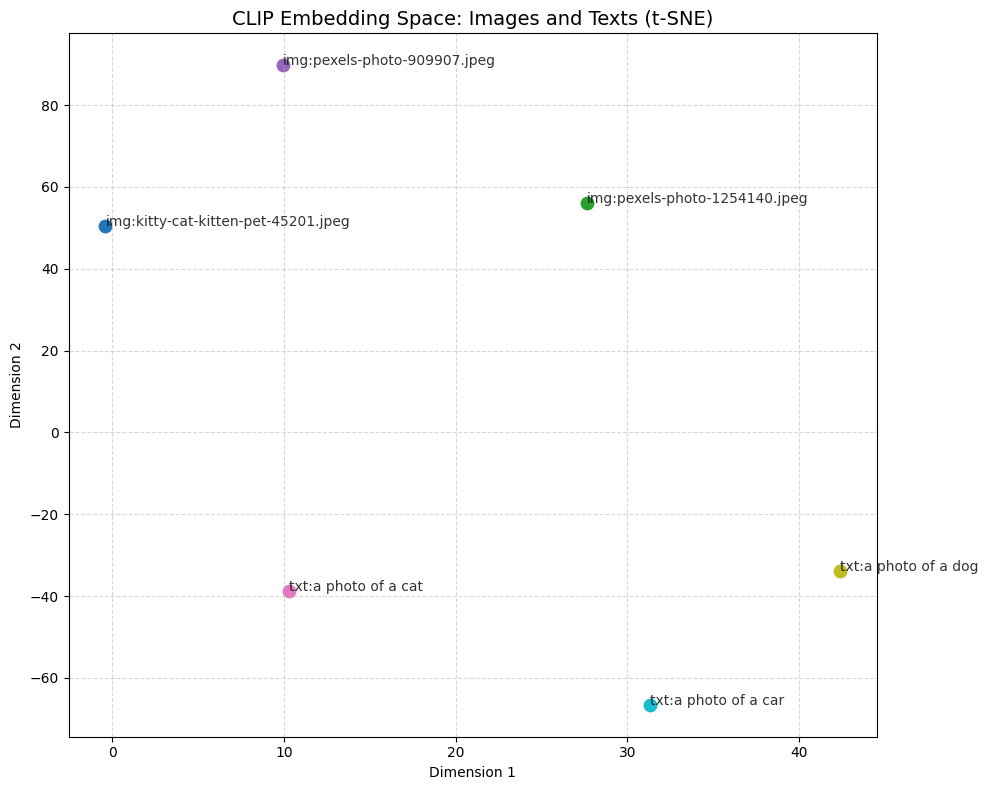

In [24]:
import torch
import requests
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np
from io import BytesIO

# Load model & processor 加载模型和处理器
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Input image (cat dog car)
image_urls = [
    "https://images.pexels.com/photos/45201/kitty-cat-kitten-pet-45201.jpeg",   # cat
    "https://images.pexels.com/photos/1254140/pexels-photo-1254140.jpeg",        # dog
    "https://images.pexels.com/photos/909907/pexels-photo-909907.jpeg"           # car
]
texts = ["a photo of a cat", "a photo of a dog", "a photo of a car"]

def load_image(url):
    """Safely loads the image and returns the RGB mode PIL Image. 安全加载图片，返回 RGB 模式 PIL Image"""
    response = requests.get(url, timeout=10)
    response.raise_for_status()  # If the HTTP status code is not 200, an exception is thrown. 如果 HTTP 状态码不是 200 则抛出异常
    img = Image.open(BytesIO(response.content)).convert('RGB')
    return img

all_embeds = []
labels = []

# Extracting Image Embeddings 提取图像嵌入
for url in image_urls:
    try:
        img = load_image(url)
        inputs = processor(images=img, return_tensors="pt")
        with torch.no_grad():
            vision_outputs = model.vision_model(pixel_values=inputs['pixel_values'])
            img_feat = model.visual_projection(vision_outputs.pooler_output)
            img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
        all_embeds.append(img_feat.squeeze().numpy())
        labels.append(f"img:{url.split('/')[-1]}")
        print(f"Loaded image: {url}")
    except Exception as e:
        print(f"Failed to load {url}: {e}")

# Extracting text Embeddings提取文本嵌入
for txt in texts:
    text_inputs = processor(text=txt, return_tensors="pt", padding=True)
    with torch.no_grad():
        text_outputs = model.text_model(
            input_ids=text_inputs['input_ids'],
            attention_mask=text_inputs['attention_mask']
        )
        txt_feat = model.text_projection(text_outputs.pooler_output)
        txt_feat = txt_feat / txt_feat.norm(dim=-1, keepdim=True)
    all_embeds.append(txt_feat.squeeze().numpy())
    labels.append(f"txt:{txt}")

# Check the sample size to avoid t-SNE parameter errors. 检查样本数，避免 t-SNE 参数错误
n_samples = len(all_embeds)
if n_samples < 2:
    print("Not enough samples for t-SNE. Please check image URLs or network.")
else:
    # The perplexity must be less than the number of samples必须小于样本数，set it: min(3, n_samples-1)
    perplexity = min(3, n_samples - 1)
    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
    embeds_2d = tsne.fit_transform(np.array(all_embeds))

    # Drawing 绘图
    plt.figure(figsize=(10, 8))
    colors = plt.cm.tab10(np.linspace(0, 1, n_samples))
    for i, (x, y) in enumerate(embeds_2d):
        plt.scatter(x, y, color=colors[i], s=80)
        plt.annotate(labels[i], (x, y), fontsize=10, alpha=0.8)
    plt.title("CLIP Embedding Space: Images and Texts (t-SNE)", fontsize=14)
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


Task 4: Reflection:

1. What is the training objective of CLIP? Why is it called "contrastive learning"?

Answer:
CLIP is trained using a contrastive loss (InfoNCE). The model learns to predict which image and which text belong together by maximizing the cosine similarity of paired (image, text) embeddings while minimizing the similarity of unpaired pairs. It is called "contrastive learning" because the model contrasts positive pairs (correct image-text matches) against negative pairs (incorrect matches), pushing the embeddings of positive pairs closer and negative pairs apart.


2. How does CLIP achieve zero‑shot classification?

Answer:

-CLIP performs zero‑shot classification by:

-Encoding the query image into an embedding vector.

-Encoding candidate class labels into text embeddings (e.g., using prompts like "a photo of a {class}").

-Computing cosine similarities between the image embedding and each text embedding.

-Selecting the class label with the highest similarity as the prediction.
No additional training or fine‑tuning is required, hence "zero‑shot".


3. What are the limitations of CLIP?

Answer:

-Poor performance on fine‑grained classification tasks (e.g., distinguishing dog breeds).

-Sensitive to the phrasing of text prompts (e.g., "a photo of a cat" works better than "cat").

-Inherits biases from its training data (e.g., gender or racial stereotypes).

-Lacks true compositional understanding (e.g., fails at "a horse riding an astronaut").

-Requires significant computational resources for training and inference on large datasets.

4. How does CLIP relate to VLM2Vec or Alpamayo1.5 + word2vec?

Answer:

-CLIP provides a foundation for vision‑language representation learning.

-VLM2Vec extends CLIP‑like models to produce better vector embeddings for retrieval tasks (e.g., search, clustering) by fine‑tuning with contrastive objectives on large‑scale multimodal data.

-Alpamayo1.5 + word2vec might refer to a pipeline that uses a CLIP‑style visual encoder combined with word2vec semantic vectors (or a fine‑tuned Alpamayo model) to generate dense embeddings for visual data, which can then be used for downstream tasks like similarity search or classification. Understanding CLIP’s contrastive learning and embedding space is essential for grasping these advanced models.